In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from sklearn.model_selection import train_test_split
from collections import defaultdict

In [2]:
def get_avg_error(df: pd.DataFrame) -> float:
    eps = 1e-8
    return (abs(df["Predicted CPI"] - df["cpi"]) / (df["cpi"] + eps)).mean() * 100

# Spec V1

## Spec V1 Prep

In [3]:
df_v1 = pd.read_csv("results/spec_v1/training_data_with_predictions.csv")

In [4]:
df_v2 = pd.read_csv("results/spec_v2/training_data_with_predictions.csv")

In [9]:
plots_dir = "results/spec_v2/plots"
os.makedirs(plots_dir, exist_ok=True)

## Error Analysis Per Benchmark 

In [26]:
total_percent_error = get_avg_error(df)
print(f"Total percent error for all benchmarks: {total_percent_error}")

Total percent error for all benchmarks: 2.20367715594492


In [6]:
v1_benchmark_errors = {}
for benchmark in df_v1["benchmark"].unique():
    df_benchmark = df_v1[df_v1["benchmark"] == benchmark]
    total_percent_error = get_avg_error(df_benchmark)
    v1_benchmark_errors[benchmark] = total_percent_error
v2_benchmark_errors = {}
for benchmark in df_v2["benchmark"].unique():
    df_benchmark = df_v2[df_v2["benchmark"] == benchmark]
    total_percent_error = get_avg_error(df_benchmark)
    v2_benchmark_errors[benchmark] = total_percent_error
    

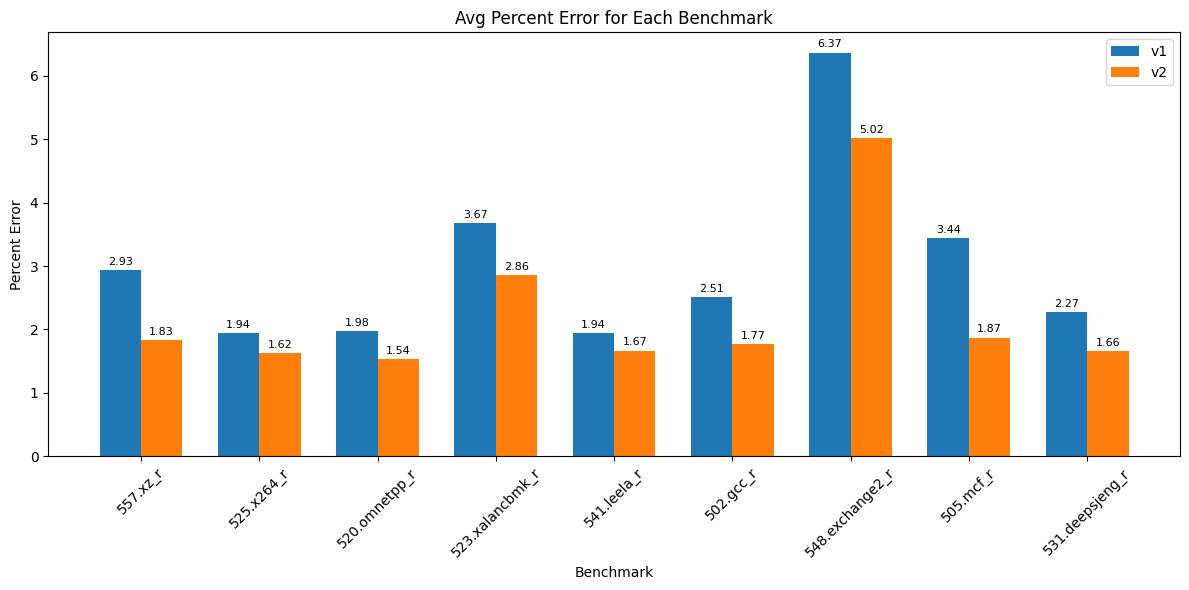

In [10]:
benchmarks = list(v1_benchmark_errors.keys())
x = np.arange(len(benchmarks))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, [v1_benchmark_errors[b] for b in benchmarks], width, label='v1')
rects2 = ax.bar(x + width/2, [v2_benchmark_errors[b] for b in benchmarks], width, label='v2')

ax.set_xlabel('Benchmark')
ax.set_ylabel('Percent Error')
ax.set_title('Avg Percent Error for Each Benchmark')
ax.set_xticks(x)
ax.set_xticklabels(benchmarks, rotation=45)
ax.legend()

# Add text errors for both bars
for i, b in enumerate(benchmarks):
    ax.text(x[i] - width/2, v1_benchmark_errors[b] + 0.05, f"{v1_benchmark_errors[b]:.2f}", ha='center', va='bottom', fontsize=8)
    ax.text(x[i] + width/2, v2_benchmark_errors[b] + 0.05, f"{v2_benchmark_errors[b]:.2f}", ha='center', va='bottom', fontsize=8)

fig.tight_layout()
plt.show()
fig.savefig(os.path.join(plots_dir, "spec_benchmark_errors.png"), bbox_inches='tight')

## Error Analysis Per Config 

In [18]:
PARAM_VALUES = {
    "int_reg_issue_width": list(range(1, 8 + 1)),
    "int_mult_div_issue_width": list(range(1, 8 + 1)),
    "fp_reg_issue_width": list(range(1, 8 + 1)),
    "fp_mult_div_issue_width": list(range(1, 8 + 1)),
    "read_port_issue_width": list(range(1, 8 + 1)),
    "rdwr_port_issue_width": list(range(1, 8 + 1)),
    "simd_unit_issue_width": [1],
    "fetch_width": list(range(1, 12 + 1)),
    "decode_width": list(range(1, 12 + 1)),
    "rename_width": list(range(1, 12 + 1)),
    "commit_width": list(range(1, 12 + 1)),
    "rob_size": list(range(1, 1024 + 1)),
    "lq_entries": list(range(1, 256 + 1)),
    "sq_entries": list(range(1, 256 + 1)),
    "branch_predictor": ["local", "tage"],
    "l1d_size": ["16KiB", "32KiB", "64KiB", "128KiB", "256KiB"],
    "l1i_size": ["16KiB", "32KiB", "64KiB", "128KiB", "256KiB"],
    "l2_size": ["512KiB", "1MiB", "2MiB", "4MiB"],
    "max_icache_fills": list(range(1, 32 + 1)),
    "stride_prefetcher_degree": [0, 4],
}

In [19]:
param_columns = list(PARAM_VALUES.keys())

In [20]:
param_columns_wo_bp = ['commit_width', 'decode_width', 'fetch_width',
       'fp_mult_div_issue_width', 'fp_reg_issue_width',
       'int_mult_div_issue_width', 'int_reg_issue_width', 'l1d_size',
       'l1i_size', 'l2_size', 'lq_entries', 'max_icache_fills',
       'rdwr_port_issue_width', 'read_port_issue_width', 'rename_width',
       'rob_size', 'simd_unit_issue_width', 'sq_entries',
       'stride_prefetcher_degree']

In [21]:
os.makedirs(os.path.join(plots_dir, "param_errors"), exist_ok=True)
for param in param_columns_wo_bp:
    param_errors = {}
    for value in PARAM_VALUES[param]:
        df_param = df[df[param] == value]
        param_errors[value] = get_avg_error(df_param)
    fig = plt.figure(figsize=(10, 6))
    plt.bar(param_errors.keys(), param_errors.values())
    plt.xlabel(param)
    plt.ylabel("Percent Error")
    plt.title(f"Error Analysis for {param}")
    fig.savefig(os.path.join(plots_dir, "param_errors", f"{param}_errors.png"))
    plt.close(fig)
    

In [22]:
os.makedirs(os.path.join(plots_dir, "param_errors_per_benchmark"), exist_ok=True)
benchmarks = sorted(df["benchmark"].unique())
for param in param_columns_wo_bp:
    values = PARAM_VALUES[param]
    # errors[benchmark][i] = avg % error for that param value index i
    errors_by_benchmark = {b: [] for b in benchmarks}
    for value in values:
        df_param = df[df[param] == value]
        for benchmark in benchmarks:
            df_b = df_param[df_param["benchmark"] == benchmark]
            errors_by_benchmark[benchmark].append(get_avg_error(df_b))

    x = np.arange(len(values))
    n_b = len(benchmarks)
    width = 0.8 / max(n_b, 1)

    fig, ax = plt.subplots(figsize=(max(10, len(values) * 0.35), 6))
    for i, benchmark in enumerate(benchmarks):
        offset = (i - (n_b - 1) / 2) * width
        ax.bar(x + offset, errors_by_benchmark[benchmark], width, label=benchmark)

    ax.set_xticks(x)
    ax.set_xticklabels(values, rotation=45, ha="right")
    ax.set_xlabel(param)
    ax.set_ylabel("Percent Error")
    ax.set_title(f"Percent error by {param} (by benchmark)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig(
        os.path.join(plots_dir, "param_errors_per_benchmark", f"{param}_errors.png"),
        bbox_inches="tight",
    )
    plt.close(fig)


## OOD Analysis

In [7]:
sweep_dir = "sweep_results/ood_peregrine"

In [8]:
summary_file = os.path.join(sweep_dir, "summary.txt")
with open(summary_file, "r") as f:
    summary = f.read()

In [9]:
ood_benchmark_errors = {}
bmark = ""
for line in summary.split("\n"):
    if bmark:
        ood_benchmark_errors[bmark] = float(line.split(": ")[1].split("%")[0].strip())
        bmark = ""
    elif "Out-of-distribution benchmark: " in line:
        bmark = line.split(": ")[1].strip()

print(ood_benchmark_errors)

{'branch_storm': 368.93, 'collatz': 58.87, 'dhrystone': 47.66, 'linpack': 103.84, 'sieve': 41.23, 'sparse': 5300.04, 'towers': 174.73, 'whetstone': 37.26}


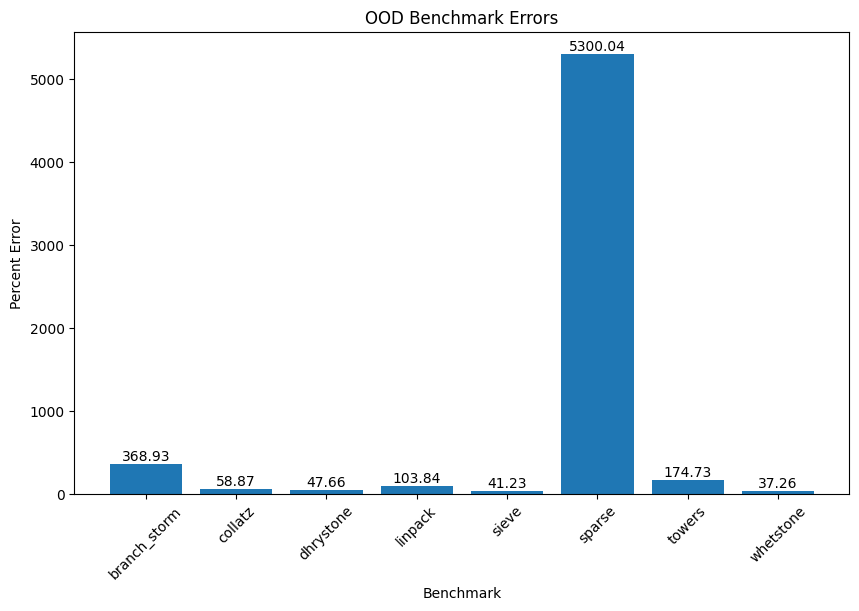

In [10]:
fig = plt.figure(figsize=(10, 6))
plt.bar(ood_benchmark_errors.keys(), ood_benchmark_errors.values())
for i, (benchmark, error) in enumerate(ood_benchmark_errors.items()):
    plt.text(i, error + 0.05, f"{error:.2f}", ha='center', va='bottom')
plt.xlabel("Benchmark")
plt.xticks(rotation=45)
plt.ylabel("Percent Error")
plt.title("OOD Benchmark Errors")
plt.show()
fig.savefig(os.path.join(sweep_dir, "ood_benchmark_errors.png"), bbox_inches='tight')

# Spec V2: With multiple traces per benchmark

In [3]:
dataset = pd.read_csv("training_data/ronamol_spec_training_data_v2.csv")

In [64]:
drop_benchmarks = []
test_size = None
test_benchmarks = ""
test_regions = 0.25
test_configs = 0.25

In [65]:
if drop_benchmarks:
    drop_list = [b.strip() for b in drop_benchmarks.split(",") if b.strip()]
    if drop_list:
        before = len(dataset)
        dataset = dataset[~dataset["benchmark"].isin(drop_list)]
        after = len(dataset)
        print(f"Dropped benchmarks {drop_list}: {before - after} rows removed, {after} remaining.")

if test_size:
    print(f"Using train/test split with test size {test_size}")
    train_dataset, test_dataset = train_test_split(dataset, test_size=test_size, random_state=42)
else:
    data_points = dataset.shape[0]

    train_dataset = dataset
    test_dataset = None

    if test_configs:
        config_columns = ['branch_predictor', 'commit_width', 'decode_width', 'fetch_width', 'fp_mult_div_issue_width', 'fp_reg_issue_width',
                            'int_mult_div_issue_width', 'int_reg_issue_width', 'l1d_size', 'l1i_size', 'l2_size', 'lq_entries', 
                            'max_icache_fills', 'rdwr_port_issue_width', 'read_port_issue_width', 'rename_width', 'rob_size', 
                            'simd_unit_issue_width', 'sq_entries', 'stride_prefetcher_degree']

        configs = dataset.groupby(config_columns).size().reset_index()[config_columns]

        configs_shuffled = configs.sample(frac=1, random_state=42).reset_index(drop=True)
        num_configs = len(configs_shuffled)
        split_idx = int(num_configs * test_configs)

        test_configs_df = configs_shuffled.iloc[:split_idx]
        
        print(f"Moving {len(test_configs_df)} configurations ({test_configs:.1%}) to test set")

        test_dataset = dataset.merge(test_configs_df, on=config_columns, how='inner')
        train_dataset = dataset.merge(test_configs_df, on=config_columns, how='outer', indicator=True).query('_merge == "left_only"').drop(columns=['_merge'])

    if test_regions:
        print(f"Moving {test_regions:.1%} of regions from each benchmark to test set")
        if test_dataset is None:
            test_dataset = train_dataset
        for benchmark in train_dataset["benchmark"].unique():
            benchmark_regions = dataset[dataset["benchmark"] == benchmark]["ff_instructions"].unique()
            num_test_regions = int(test_regions * len(benchmark_regions))

            if num_test_regions > 0:
                benchmark_test_regions = np.random.choice(benchmark_regions, size=num_test_regions, replace=False)
                
                benchmark_mask = train_dataset["benchmark"] == benchmark
                region_mask = ~train_dataset["ff_instructions"].isin(benchmark_test_regions)
                print(f" - Benchmark: {benchmark}, train_rows = {sum(benchmark_mask & region_mask)} / {sum(benchmark_mask)} = {sum(benchmark_mask & region_mask) / sum(benchmark_mask):.2%}")
                train_dataset = train_dataset[~benchmark_mask | region_mask]
                
                benchmark_mask = test_dataset["benchmark"] == benchmark
                region_mask = test_dataset["ff_instructions"].isin(benchmark_test_regions)
                print(f" - Benchmark: {benchmark}, test_rows = {sum(benchmark_mask & region_mask)} / {sum(benchmark_mask)} = {sum(benchmark_mask & region_mask) / sum(benchmark_mask):.2%}")
                test_dataset = test_dataset[~benchmark_mask | region_mask]
            else:
                raise ValueError(f"num_test_regions is 0 for benchmark {benchmark}")
    elif test_benchmarks:
        test_benchmarks_names = [b.strip() for b in test_benchmarks.split(",") if b.strip()]
        print(f"Moving benchmarks {test_benchmarks} to test set")

        if test_dataset is None:
            test_dataset = train_dataset

        mask = train_dataset["benchmark"].isin(test_benchmarks_names)
        train_dataset = train_dataset[~mask]
        mask = test_dataset["benchmark"].isin(test_benchmarks_names)
        test_dataset = test_dataset[mask]

print(f"Final split: {len(train_dataset)} train, {len(test_dataset)} test ({len(test_dataset)/(len(train_dataset)+len(test_dataset)):.2%} test)")
print(f"Train dataset shape: {train_dataset.shape}")
print(f"Test dataset shape: {test_dataset.shape}")

Moving 1024 configurations (25.0%) to test set
Moving 25.0% of regions from each benchmark to test set
 - Benchmark: 505.mcf_r, train_rows = 147456 / 196608 = 75.00%
 - Benchmark: 505.mcf_r, test_rows = 16384 / 65536 = 25.00%
 - Benchmark: 520.omnetpp_r, train_rows = 147456 / 196608 = 75.00%
 - Benchmark: 520.omnetpp_r, test_rows = 16384 / 65536 = 25.00%
 - Benchmark: 523.xalancbmk_r, train_rows = 73728 / 98304 = 75.00%
 - Benchmark: 523.xalancbmk_r, test_rows = 8192 / 32768 = 25.00%
 - Benchmark: 541.leela_r, train_rows = 147456 / 196608 = 75.00%
 - Benchmark: 541.leela_r, test_rows = 16384 / 65536 = 25.00%
 - Benchmark: 548.exchange2_r, train_rows = 147456 / 196608 = 75.00%
 - Benchmark: 548.exchange2_r, test_rows = 16384 / 65536 = 25.00%
 - Benchmark: 531.deepsjeng_r, train_rows = 73728 / 98304 = 75.00%
 - Benchmark: 531.deepsjeng_r, test_rows = 8192 / 32768 = 25.00%
 - Benchmark: 557.xz_r, train_rows = 73728 / 98304 = 75.00%
 - Benchmark: 557.xz_r, test_rows = 8192 / 32768 = 25.00%

### Confirm Split along configs and program regions

In [55]:
# Ensure no duplicate rows between train_dataset and test_dataset
# Check based on the values of config_columns, benchmark, and ff_instructions (indexes are irrelevant)
key_columns = config_columns + ["benchmark", "ff_instructions"]
shared_keys = pd.merge(
    train_dataset[key_columns],
    test_dataset[key_columns],
    on=key_columns,
    how="inner",
)
if not shared_keys.empty:
    print("Found duplicate rows between train_dataset and test_dataset")

if train_dataset.duplicated().any():
    print(f"train_dataset has {train_dataset.duplicated().sum()} duplicate rows")

if test_dataset.duplicated().any():
    print(f"test_dataset has {test_dataset.duplicated().sum()} duplicate rows")

In [56]:
shared_configs = pd.merge(
    train_dataset[config_columns],
    test_dataset[config_columns],
    on=config_columns,
    how="inner",
)
if not shared_configs.empty:
    print("Found duplicate configs between train_dataset and test_dataset. Expected if test_configs=None")

In [57]:
regions_columns = ["benchmark", "ff_instructions"]
# train_dataset[regions_columns]
test_regions = set(test_dataset[regions_columns].itertuples(index=False))
train_regions = set(train_dataset[regions_columns].itertuples(index=False))
shared_regions = test_regions.intersection(train_regions)
if shared_regions:
    print("Found duplicate regions between train_dataset and test_dataset. Expected if test_regions=None")

### Visualize Train Test Split

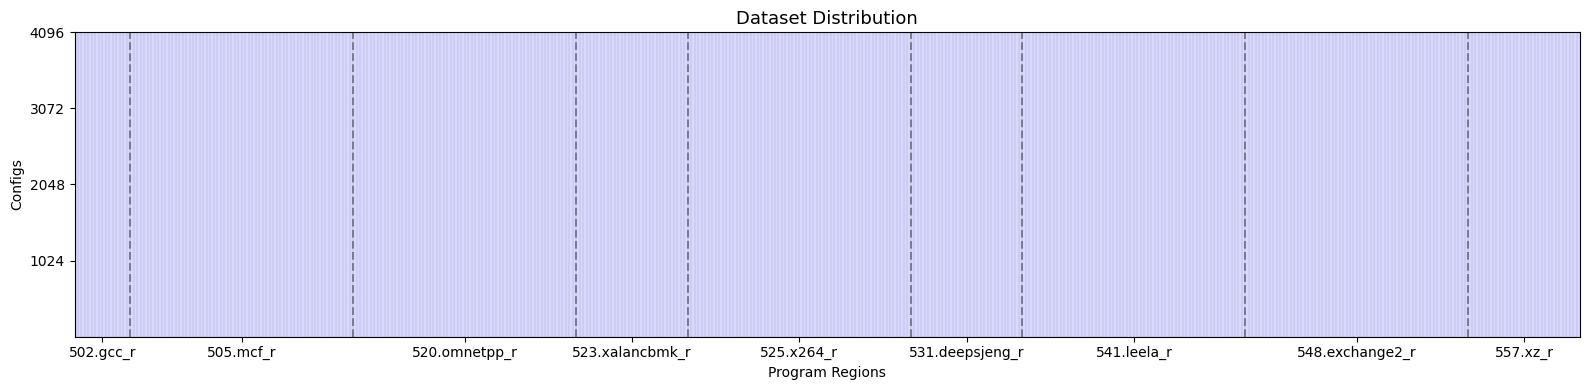

In [ ]:
benchmarks = dataset["benchmark"].unique()
program_regions = dataset.groupby(["benchmark", "ff_instructions"]).size().reset_index(name="count")[["benchmark", "ff_instructions"]]
regions_per_benchmark = program_regions.groupby("benchmark").size().reset_index(name="count")

config_columns = [
    'branch_predictor', 'commit_width', 'decode_width', 'fetch_width', 
    'fp_mult_div_issue_width', 'fp_reg_issue_width', 'int_mult_div_issue_width', 
    'int_reg_issue_width', 'l1d_size', 'l1i_size', 'l2_size', 'lq_entries', 
    'max_icache_fills', 'rdwr_port_issue_width', 'read_port_issue_width', 
    'rename_width', 'rob_size', 'simd_unit_issue_width', 'sq_entries', 
    'stride_prefetcher_degree'
]
configs = dataset.groupby(config_columns).size().reset_index(name="count")[config_columns]
num_configs = len(configs)

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(16, 4))

# Calculate normalized widths for each benchmark
region_counts = regions_per_benchmark["count"].values
total_regions = program_regions.shape[0]
benchmark_widths = region_counts / total_regions

# Plot program regions for full dataset
x_start = 0
for i, (benchmark, n_regions) in enumerate(zip(regions_per_benchmark["benchmark"], regions_per_benchmark["count"])):
    width = benchmark_widths[i]
    # Find the program regions for this benchmark
    benchmark_regions = program_regions[program_regions["benchmark"] == benchmark]["ff_instructions"].unique()
    # For each region, plot a vertical band
    region_width = width / n_regions if n_regions else 0
    for j, region in enumerate(benchmark_regions):
        # Each region gets a box spanning full y range (for all configs)
        left = x_start + j * region_width
        rect = plt.Rectangle(xy=(left, 0), width=region_width, height=num_configs-1, 
                             alpha=0.15, facecolor="blue", edgecolor='black', linewidth=0.25)
        ax.add_patch(rect)
    # Optionally annotate benchmark boundaries
    ax.axvline(x=x_start, color="black", linestyle="--", alpha=0.4)
    x_start += width

# Ticks for configs (y-axis)
config_tick_labels = [f"{int(round(i*num_configs/4))}" for i in range(5)]
config_tick_pos = [i*num_configs/4 - 1 for i in range(5)]
ax.set_yticks(config_tick_pos)
ax.set_yticklabels(config_tick_labels)
ax.set_ylabel("Configs")

# X-axis ticks: at the edge of each benchmark region, and midpoint
x_tick_positions = []
x_tick_labels = []
x_start = 0
for i, (benchmark, n_regions) in enumerate(zip(regions_per_benchmark["benchmark"], regions_per_benchmark["count"])):
    width = benchmark_widths[i]
    mid_region = x_start + width/2
    x_tick_positions.append(mid_region)
    x_tick_labels.append(benchmark)
    x_start += width
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, ha="center")
ax.set_xlabel("Program Regions")


# # Plot train and test regions
# train_benchmarks = train_dataset["benchmark"].unique()
# train_program_regions = train_dataset.groupby(["benchmark", "ff_instructions"]).size().reset_index(name="count")[["benchmark", "ff_instructions"]]
# train_regions_per_benchmark = train_program_regions.groupby("benchmark").size().reset_index(name="count")

# train_configs = train_dataset.groupby(config_columns).size().reset_index(name="count")[config_columns]
# num_train_configs = len(train_configs)




ax.set_title("Dataset Distribution", fontsize=13)
ax.set_xlim(0,1)
ax.set_ylim(0, num_configs-1 if num_configs > 1 else 1)
plt.tight_layout()
plt.show()


# OOD Analysis

In [9]:
sweep_dirs = [
    # "sweep_results/ood_spec_v1.1",
    "sweep_results/ood_spec_v2",
    "sweep_results/ood_spec_v3",
]
sweep_ood_benchmark_errors = {}
for sweep_dir in sweep_dirs:
    with open(os.path.join(sweep_dir, "summary.txt"), "r") as f:
        summary = f.read()
    bmark = ""
    ood_benchmark_errors = {}
    for line in summary.split("\n"):
        if bmark:
            ood_benchmark_errors[bmark] = float(line.split(": ")[1].split("%")[0].strip())
            bmark = ""
        elif "Out-of-distribution benchmark: " in line:
            bmark = line.split(": ")[1].strip()
    sweep_ood_benchmark_errors[sweep_dir] = ood_benchmark_errors

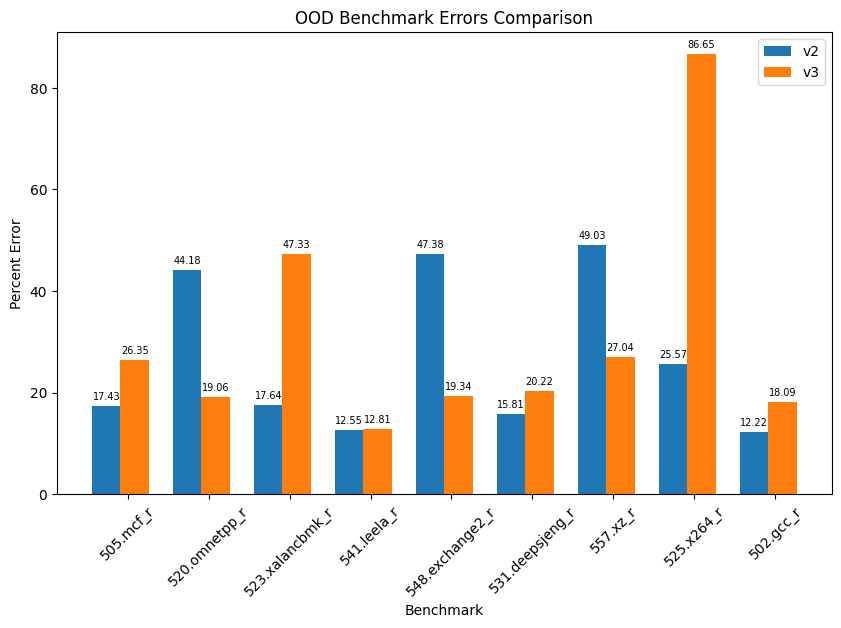

In [10]:
benchmarks = list(ood_benchmark_errors.keys())
# Ensure both dicts have the same order and all keys
sweep_errors = [sweep_ood_benchmark_errors[sweep_dir].get(bmark, np.nan) for bmark in benchmarks]

x = np.arange(len(benchmarks))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
num_sweeps = len(sweep_ood_benchmark_errors)
for i, (sweep_dir, errors) in enumerate(sweep_ood_benchmark_errors.items()):
    offsets = x + (i - num_sweeps / 2) * width / num_sweeps * 2 + width/(2*num_sweeps)
    rects = ax.bar(offsets, list(errors.values()), width / num_sweeps * 2, label=sweep_dir.split("_")[-1])

    # Attach a text label above each bar
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    fontsize=7,
                    ha='center', va='bottom')

ax.set_xlabel('Benchmark')
ax.set_ylabel('Percent Error')
ax.set_title('OOD Benchmark Errors Comparison')
ax.set_xticks(x)
ax.set_xticklabels(benchmarks, rotation=45)
ax.legend()
plt.show()
fig.savefig(os.path.join(sweep_dir, "ood_benchmark_errors_compare.png"), bbox_inches='tight')

# OOD Regions Configs Split

In [2]:
sweep_dir = "sweep_results/ood_regions_configs_spec_v2"

In [3]:
summary_file = os.path.join(sweep_dir, "summary.txt")
with open(summary_file, "r") as f:
    summary = f.read()

In [7]:
"""
Test regions split: 0.00 - Test configs split: 0.125
  Final Percent Error: 3.08%
"""
ood_benchmark_errors = {}
lines = summary.split("\n")
i = 0
while i < len(lines):
    line = lines[i]
    pat = r"Test regions split: ([0-9.]+) - Test configs split: ([0-9.]+)"
    match = re.match(pat, line)
    if match:
        test_regions_split = float(match.group(1))
        test_configs_split = float(match.group(2))
        i += 1
        line = lines[i]
        pat = r"  Final Percent Error: ([0-9.]+)%"
        match = re.match(pat, line)
        if match:
            final_percent_error = float(match.group(1))
            i += 1
            ood_benchmark_errors[(test_regions_split, test_configs_split)] = final_percent_error
    else:
        i += 1

print(ood_benchmark_errors)

{(0.0, 0.0625): 2.38, (0.0, 0.125): 3.08, (0.0, 0.1875): 3.49, (0.0, 0.25): 3.71, (0.0625, 0.0): 3.22, (0.0625, 0.0625): 5.24, (0.0625, 0.125): 4.7, (0.0625, 0.1875): 6.48, (0.0625, 0.25): 7.61, (0.125, 0.0): 3.56, (0.125, 0.0625): 4.42, (0.125, 0.125): 4.88, (0.125, 0.1875): 5.17, (0.125, 0.25): 6.57, (0.1875, 0.0): 5.29, (0.1875, 0.0625): 5.41, (0.1875, 0.125): 5.19, (0.1875, 0.1875): 6.54, (0.1875, 0.25): 7.22, (0.25, 0.0): 4.33, (0.25, 0.0625): 5.67, (0.25, 0.125): 6.13, (0.25, 0.1875): 5.69, (0.25, 0.25): 6.74}


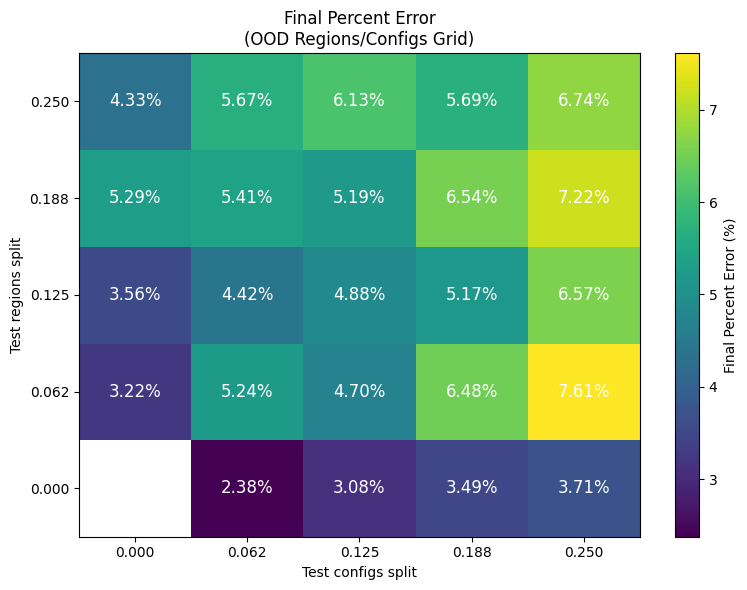

In [12]:
# Get all unique splits
region_splits = sorted({k[0] for k in ood_benchmark_errors.keys()})
config_splits = sorted({k[1] for k in ood_benchmark_errors.keys()})

# Construct grid of percent errors
error_grid = np.full((len(region_splits), len(config_splits)), np.nan)
for (region, config), val in ood_benchmark_errors.items():
    i = region_splits.index(region)
    j = config_splits.index(config)
    error_grid[i, j] = val

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(error_grid, origin="lower", aspect="auto", cmap="viridis")

# Set axis labels and ticks
ax.set_xticks(np.arange(len(config_splits)))
ax.set_yticks(np.arange(len(region_splits)))
ax.set_xticklabels([f"{x:.3f}" for x in config_splits])
ax.set_yticklabels([f"{x:.3f}" for x in region_splits])
ax.set_xlabel("Test configs split")
ax.set_ylabel("Test regions split")
plt.title("Final Percent Error\n(OOD Regions/Configs Grid)")

# Show values in cells
for i in range(len(region_splits)):
    for j in range(len(config_splits)):
        val = error_grid[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}%", ha="center", va="center", color="w", fontsize=12)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Final Percent Error (%)")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(sweep_dir, "ood_regions_configs_grid.png"), bbox_inches='tight')

In [3]:
df_spec_v2 = pd.read_csv("training_data/ronamol_spec_training_data_v2.csv")

In [25]:
samples = df_spec_v2.groupby(['benchmark', 'ff_instructions']).apply(lambda g: g.sample(1, random_state=42)).reset_index()
samples.drop(columns=["level_2"], inplace=True)
train_dataset, test_dataset = train_test_split(samples, test_size=0.25, random_state=42)

In [26]:
samples

,benchmark,ff_instructions,cpi,branch_predictor,commit_width,decode_width,fetch_width,fp_mult_div_issue_width,fp_reg_issue_width,int_mult_div_issue_width,...,prog_unique_load_pages,prog_unique_store_pages,cache_exec_mean,cache_exec_p50,cache_exec_p75,cache_exec_p95,cache_fetch_mean,cache_fetch_p50,cache_fetch_p75,cache_fetch_p95
0,502.gcc_r,1000000,2.774680,tage,11,1,1,2,3,1,...,62.0,21.0,1.467764,1.0,1.0,3.0,2.215999,2.0,2.0,2.0
1,502.gcc_r,1880000,2.258030,tage,11,1,1,2,3,1,...,18.0,8.0,1.681427,1.0,1.0,3.0,2.002816,2.0,2.0,2.0
2,502.gcc_r,2760000,2.934560,tage,11,1,1,2,3,1,...,89.0,58.0,2.277022,1.0,1.0,3.0,2.652418,2.0,2.0,2.0
3,502.gcc_r,3640000,2.822424,tage,11,1,1,2,3,1,...,79.0,49.0,2.301498,1.0,1.0,3.0,2.670215,2.0,2.0,2.0
4,502.gcc_r,4520000,2.991520,tage,11,1,1,2,3,1,...,93.0,56.0,2.267692,1.0,1.0,3.0,2.618101,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,557.xz_r,686440000,1.555070,tage,11,1,1,2,3,1,...,6.0,1.0,1.175921,1.0,1.0,3.0,2.001017,2.0,2.0,2.0
428,557.xz_r,708160000,1.556330,tage,11,1,1,2,3,1,...,6.0,1.0,1.176032,1.0,1.0,3.0,2.001017,2.0,2.0,2.0
429,557.xz_r,729880000,1.542240,tage,11,1,1,2,3,1,...,6.0,1.0,1.174831,1.0,1.0,3.0,2.001026,2.0,2.0,2.0
430,557.xz_r,751600000,1.552660,tage,11,1,1,2,3,1,...,5.0,1.0,1.175509,1.0,1.0,3.0,2.001019,2.0,2.0,2.0


In [27]:
len(samples)

432

In [28]:
assert len(train_dataset) == len(train_dataset.drop_duplicates()), "Train dataset has duplicates"
assert len(test_dataset) == len(test_dataset.drop_duplicates()), "Test dataset has duplicates"
combined_dataset = pd.concat([train_dataset, test_dataset])
assert len(combined_dataset.drop_duplicates()) == len(combined_dataset), "No duplicates between train and test datasets"

In [29]:
train_dataset[train_dataset.duplicated()]

,benchmark,ff_instructions,cpi,branch_predictor,commit_width,decode_width,fetch_width,fp_mult_div_issue_width,fp_reg_issue_width,int_mult_div_issue_width,...,prog_unique_load_pages,prog_unique_store_pages,cache_exec_mean,cache_exec_p50,cache_exec_p75,cache_exec_p95,cache_fetch_mean,cache_fetch_p50,cache_fetch_p75,cache_fetch_p95


# OOD Onboarding Cost Analysis

In [11]:
sweep_dir = "sweep_results/ood_spec_v3_onboarding"
with open(os.path.join(sweep_dir, "summary.txt"), "r") as f:
    summary = f.read()
bmark = ""
ood_train_size = 0
ood_benchmark_errors = defaultdict(dict)
for line in summary.split("\n"):
    if bmark and ood_train_size:
        ood_benchmark_errors[bmark][ood_train_size] = float(line.split(": ")[1].split("%")[0].strip())
        bmark = ""
        ood_train_size = 0
    elif "Out-of-distribution benchmark: " in line:
        pat = r"Out-of-distribution benchmark: ([^|]+) \| OOD train size: (\d+)"
        match = re.match(pat, line)
        if not match:
            raise ValueError(f"No match found for line: {line}")
        bmark = match.group(1).strip()
        ood_train_size = int(match.group(2))

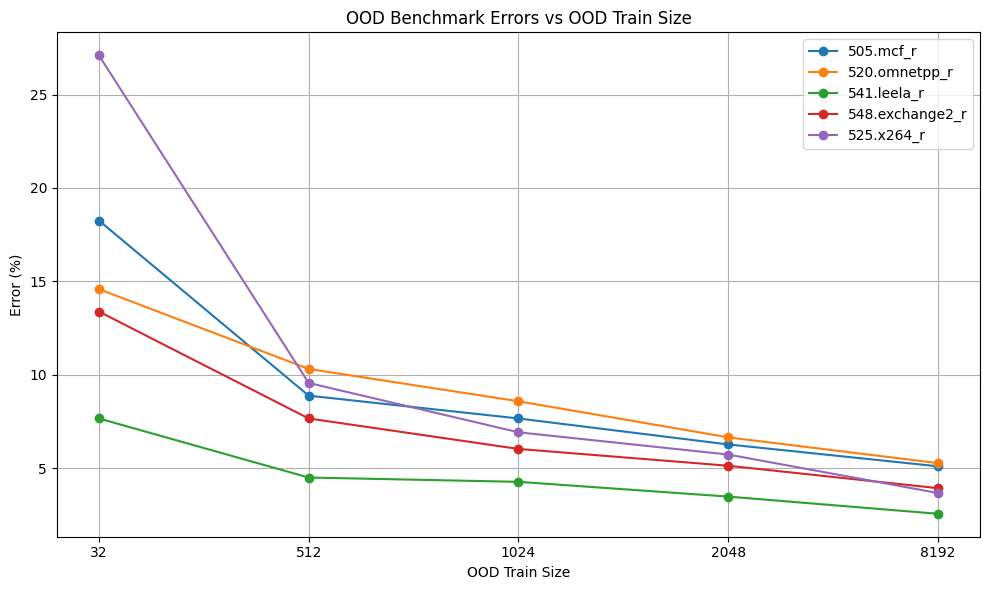

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
all_xs = sorted({x for errors in ood_benchmark_errors.values() for x in errors.keys()})
x_positions = np.arange(len(all_xs))
x_lookup = {x: i for i, x in enumerate(all_xs)}

for benchmark, errors in ood_benchmark_errors.items():
    xs = sorted(errors.keys())
    ys = [errors[x] for x in xs]
    positions = [x_lookup[x] for x in xs]
    ax.plot(positions, ys, marker='o', label=benchmark)

# ax.set_yscale('log')
ax.set_xticks(x_positions)
ax.set_xticklabels(all_xs)
ax.set_xlabel("OOD Train Size")
ax.set_ylabel("Error (%)")
ax.set_title("OOD Benchmark Errors vs OOD Train Size")
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()